In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import sklearn
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

In [2]:
kmeans = KMeans()
pca = PCA()

In [3]:
dataset= pd.read_csv("Scaled Data.csv")

In [ ]:
spearman_matrix = dataset.corr(method='spearman')
spearman_matrix

In [4]:
from matplotlib.colors import ListedColormap

my_colors = ["yellow", "purple", "red"]
custom_cmap = ListedColormap(my_colors)

In [5]:
# WORKPLACE AND THE MENTAL HEALTH THERE
features_5d = dataset[['How many employees does your company or organization have?', 'Do you currently have a mental health disorder?',
                       'Do you work remotely?', 'Benefits Or Help Provided for Mental Health']]

In [6]:
k_range = range(2, 15)
silhouette_scores =[]
for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init="auto")
    cluster_labels = kmeans.fit_predict(features_5d)

    # Calculate the average silhouette score for this K
    score = silhouette_score(features_5d, cluster_labels)
    silhouette_scores.append(score)
    print(f"For K = {k}, the average Silhouette Score is: {score:.2f}")

For K = 2, the average Silhouette Score is: 0.27
For K = 3, the average Silhouette Score is: 0.23
For K = 4, the average Silhouette Score is: 0.25
For K = 5, the average Silhouette Score is: 0.27
For K = 6, the average Silhouette Score is: 0.25
For K = 7, the average Silhouette Score is: 0.28
For K = 8, the average Silhouette Score is: 0.30
For K = 9, the average Silhouette Score is: 0.30
For K = 10, the average Silhouette Score is: 0.31
For K = 11, the average Silhouette Score is: 0.30
For K = 12, the average Silhouette Score is: 0.30
For K = 13, the average Silhouette Score is: 0.31
For K = 14, the average Silhouette Score is: 0.32


In [7]:
#WCSS 
wcss = []
wcss_range = range (2, 15)

for w in wcss_range:
    # FIXED: Uniform naming using 'kmeans_eval'
    kmeans_eval = KMeans(n_clusters=k, random_state=42, n_init= 10)
    elbow= kmeans_eval.fit(features_5d)
    wcss.append(elbow.inertia_)

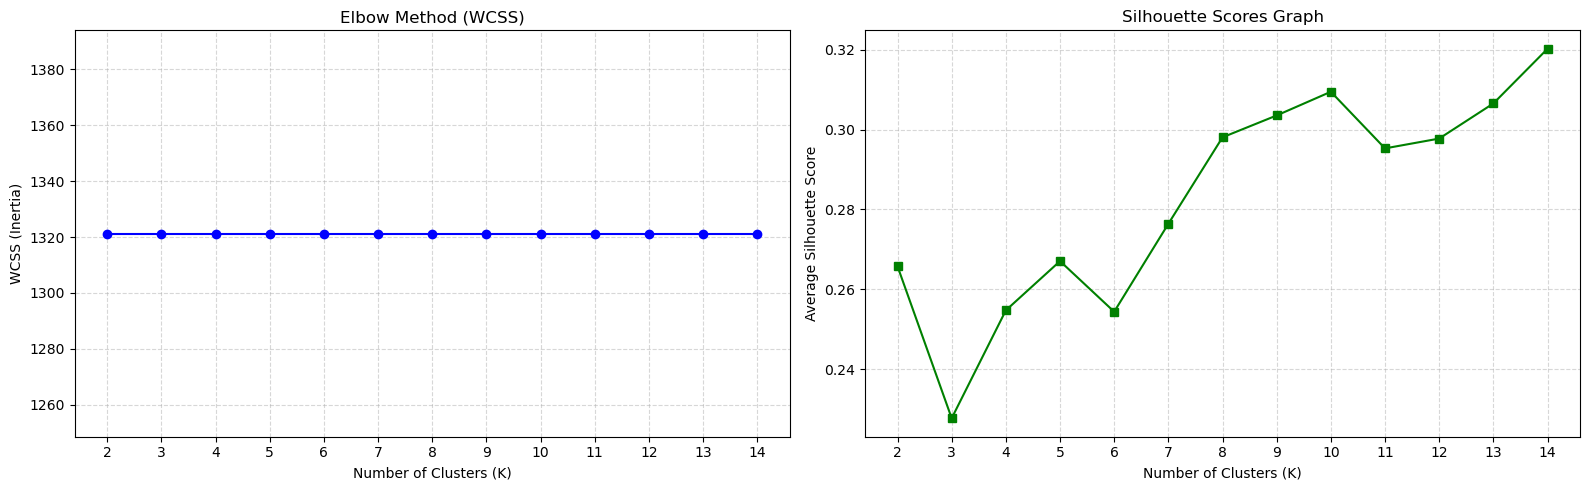

In [8]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))

# Plot Elbow Method
ax1.plot(wcss_range, wcss, marker="o", color="blue", linestyle="-")
ax1.set_title("Elbow Method (WCSS)")
ax1.set_xlabel("Number of Clusters (K)")
ax1.set_ylabel("WCSS (Inertia)")
ax1.set_xticks(wcss_range)
ax1.grid(True, linestyle="--", alpha=0.5)

# Plot Silhouette Scores
ax2.plot(k_range, silhouette_scores, marker="s", color="green", linestyle="-")
ax2.set_title("Silhouette Scores Graph")
ax2.set_xlabel("Number of Clusters (K)")
ax2.set_ylabel("Average Silhouette Score")
ax2.set_xticks(k_range)
ax2.grid(True, linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

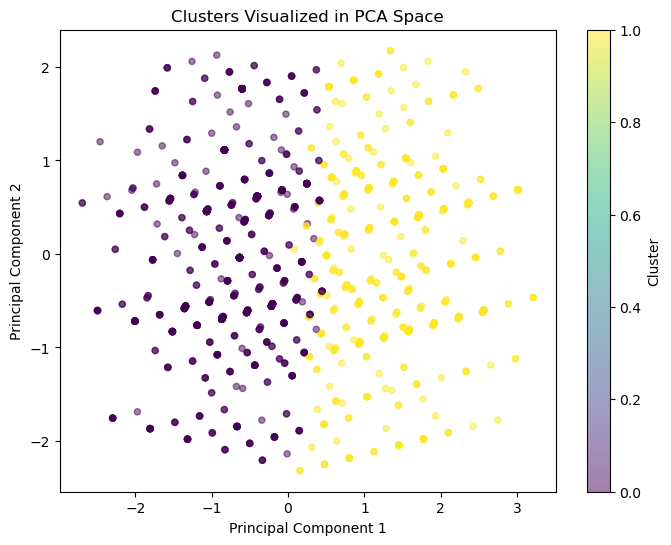

In [9]:
# WORKPLACE AND THE MENTAL HEALTH THERE

features_5d = dataset[['How many employees does your company or organization have?', 'Do you currently have a mental health disorder?',
                       'Do you work remotely?', 'Benefits Or Help Provided for Mental Health']]
kmeans_4d = KMeans(n_clusters= 2, random_state= 42)
dataset["Cluster_4cols"] = kmeans_4d.fit_predict(features_5d)

# Select the 4 columns you clustered on
# Run PCA to reduce to 2D
pca = PCA(n_components=2)
pca_result = pca.fit_transform(features_5d)

# Create a DataFrame with PC1 and PC2
pca_df = pd.DataFrame(pca_result, columns=["PC1", "PC2"])

# Add cluster labels from your dataset
pca_df["Cluster"] = dataset["Cluster_4cols"]


# Suppose you have PCA results in pca_df with columns 'PC1' and 'PC2'
# and your dataset has a cluster column 'Cluster_4cols'

plt.figure(figsize=(8,6))
plt.scatter(
    pca_df['PC1'], 
    pca_df['PC2'], 
    c=dataset['Cluster_4cols'],   # color by cluster labels
    cmap='viridis',               # color map (try 'tab10' for distinct colors)
    alpha=0.5,                    # transparency for overlap
    s=20                          # marker size
)

plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('Clusters Visualized in PCA Space')
plt.colorbar(label='Cluster')
plt.show()

For K = 2, the average Silhouette Score is: 0.27
For K = 3, the average Silhouette Score is: 0.26
For K = 4, the average Silhouette Score is: 0.23
For K = 5, the average Silhouette Score is: 0.23
For K = 6, the average Silhouette Score is: 0.25
For K = 7, the average Silhouette Score is: 0.27
For K = 8, the average Silhouette Score is: 0.29
For K = 9, the average Silhouette Score is: 0.29
For K = 10, the average Silhouette Score is: 0.31
For K = 11, the average Silhouette Score is: 0.30
For K = 12, the average Silhouette Score is: 0.31
For K = 13, the average Silhouette Score is: 0.33
For K = 14, the average Silhouette Score is: 0.33


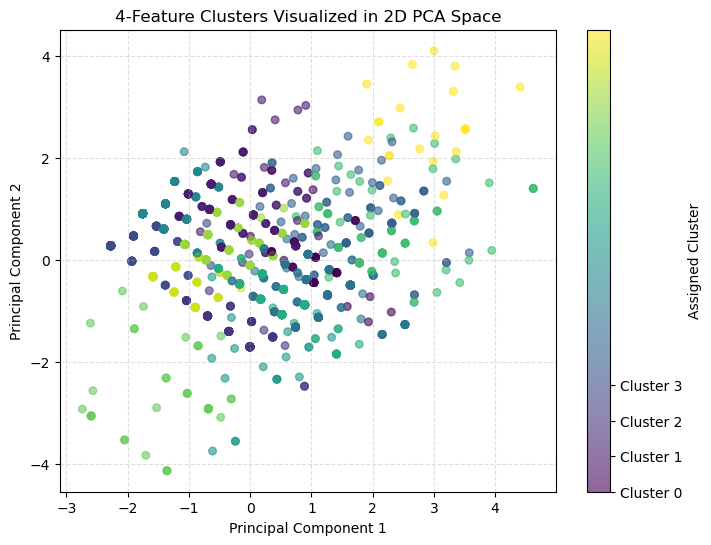

Total information retained from the 4 columns: 60.49%


In [10]:
#IF THEY HAVE MENTAL HEALTH STIGMA AND THEY ALSO HAVE SOME MENTAL ISSUE DOES IT INTERFERE WITH THEIR WORK

col1 = 'If you have a mental health issue, do you feel that it interferes with your work when being treated effectively?'
col2 = 'History of mental issues'
col3 = 'Consequences of discussing mental health'
col4= 'Fear of others behavior if mentally ill'
col5 = 'Saw negative attitude towards mental health problems (Current or Previous Workplace)'

# Ensure features_5 is a clean numeric dataframe (with encoded/scaled values)
column_list = [col1, col2, col3, col4, col5]
features_5 = dataset[column_list].dropna().copy()

#WCSS 
wcss = []
wcss_range = range (2, 15)

for w in wcss_range:
    # FIXED: Uniform naming using 'kmeans_eval'
    kmeans_eval = KMeans(n_clusters=k, random_state=42, n_init= 10)
    elbow= kmeans_eval.fit(features_5)
    wcss.append(elbow.inertia_)

    
# 2. Run K-Means and evaluate Silhouette Scores
k_range = range(2, 15)
silhouette_scores = []

for k in k_range:
    # FIXED: Uniform naming using 'kmeans_eval'
    kmeans_eval = KMeans(n_clusters=k, random_state=42, n_init="auto")
    cluster_labels = kmeans_eval.fit_predict(features_5)

    # Calculate and print the average silhouette score
    score = silhouette_score(features_5, cluster_labels)
    silhouette_scores.append(score)
    print(f"For K = {k}, the average Silhouette Score is: {score:.2f}")

# 3. Fit your final chosen model (K=4)
kmeans_4 = KMeans(n_clusters=14, random_state=42, n_init="auto")
final_labels = kmeans_4.fit_predict(features_5)

# 4. Run PCA to compress the 4D space into 2D
# FIXED: Uniform naming using 'pca_model'
pca_model = PCA(n_components=2, random_state=42)
pca_transformed_4 = pca_model.fit_transform(features_5)

# Create the final plotting DataFrame
pca_df_4 = pd.DataFrame(data=pca_transformed_4, columns=["PC1", "PC2"])
# FIXED: Read cluster labels directly from the new calculations to avoid KeyError
pca_df_4["Cluster_4cols"] = final_labels

# 5. Create the 2D Scatter Plot
plt.figure(figsize=(8, 6))
scatter = plt.scatter(
    pca_df_4["PC1"],
    pca_df_4["PC2"],
    c=pca_df_4["Cluster_4cols"],
    cmap='viridis',  # Using viridis for a clean discrete sequence
    s=30,
    alpha=0.6,
)

plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('4-Feature Clusters Visualized in 2D PCA Space')

# Handle discrete colorbar ticks for K=4 (Clusters 0, 1, 2, 3)
colorbar = plt.colorbar(scatter, ticks=[0, 1, 2, 3])
colorbar.set_label("Assigned Cluster")
colorbar.set_ticklabels(["Cluster 0", "Cluster 1", "Cluster 2", "Cluster 3"])

plt.grid(True, linestyle='--', alpha=0.4)
plt.show()

# 6. Check information retention
variance_captured = sum(pca_model.explained_variance_ratio_) * 100
print(f"Total information retained from the 4 columns: {variance_captured:.2f}%")

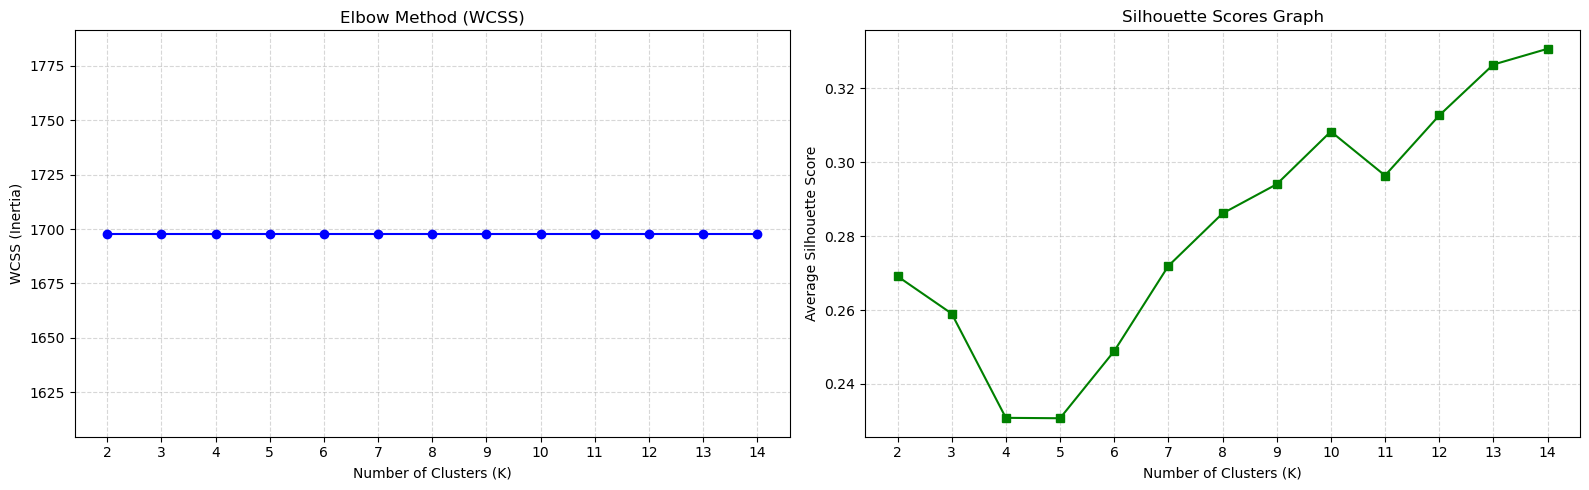

In [11]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))

# Plot Elbow Method
ax1.plot(wcss_range, wcss, marker="o", color="blue", linestyle="-")
ax1.set_title("Elbow Method (WCSS)")
ax1.set_xlabel("Number of Clusters (K)")
ax1.set_ylabel("WCSS (Inertia)")
ax1.set_xticks(wcss_range)
ax1.grid(True, linestyle="--", alpha=0.5)

# Plot Silhouette Scores
ax2.plot(k_range, silhouette_scores, marker="s", color="green", linestyle="-")
ax2.set_title("Silhouette Scores Graph")
ax2.set_xlabel("Number of Clusters (K)")
ax2.set_ylabel("Average Silhouette Score")
ax2.set_xticks(k_range)
ax2.grid(True, linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

In [ ]:
# WORKPLACE AND THE MENTAL HEALTH THERE (2 CLUSTERS USING K-MEANS, SILHOUETTE SCORE: 0.22)

'''
    'How many employees does your company or organization have?'
    'Do you currently have a mental health disorder?'
    'Do you work remotely?'
    'Benefits Or Help Provided for Mental Health'
'''


#IF THEY HAVE MENTAL HEALTH STIGMA & THEY ALSO HAVE SOME MENTAL ISSUE DOES IT INTERFERE WITH THEIR WORK (3 CLUSTERS USING K-MEANS, SILHOUETTE SCORE: 0.26)
'''
    'If you have a mental health issue, do you feel that it interferes with your work when being treated effectively?'
    'History of mental issues'
    'Consequences of discussing mental health'
    'Fear of others behavior if mentally ill'
    'Saw negative attitude towards mental health problems (Current or Previous Workplace)'
'''


# GIVEN A GOOD WORK ENVIRONMENT, & TREATMENT DOES THEIR MENTAL HEALTH STILL INTERFERE WITH WORK (3 CLUSTERS USING K-MEANS, SILHOUETTE SCORE: 0.46)
'''
    'Is your anonymity protected if you choose to take advantage of mental health or substance abuse treatment resources provided by your employer?'
    'If you have a mental health issue, do you feel that it interferes with your work when being treated effectively?'
    'Benefits Or Help Provided for Mental Health'
'''

For K = 2, the average Silhouette Score is: 0.39
For K = 3, the average Silhouette Score is: 0.46
For K = 4, the average Silhouette Score is: 0.48
For K = 5, the average Silhouette Score is: 0.52
For K = 6, the average Silhouette Score is: 0.54
For K = 7, the average Silhouette Score is: 0.56
For K = 8, the average Silhouette Score is: 0.56
For K = 9, the average Silhouette Score is: 0.58
For K = 10, the average Silhouette Score is: 0.59
For K = 11, the average Silhouette Score is: 0.63
For K = 12, the average Silhouette Score is: 0.61
For K = 13, the average Silhouette Score is: 0.62
For K = 14, the average Silhouette Score is: 0.64


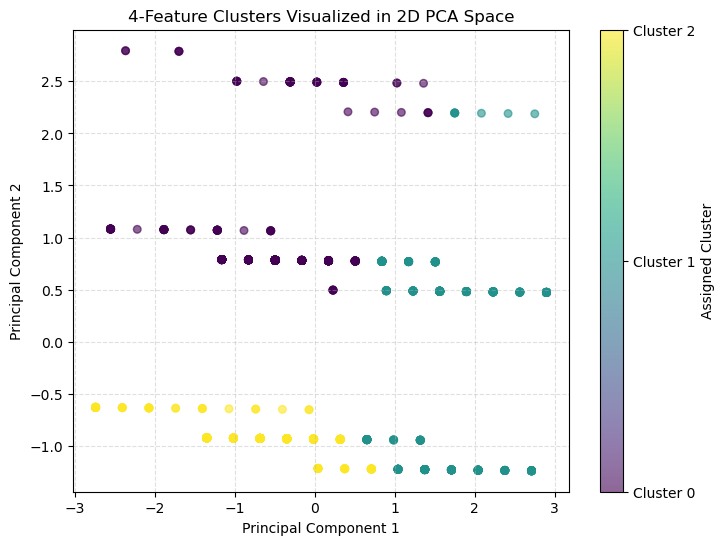

Total information retained from the 4 columns: 80.20%


In [12]:
# PROTECT ANONYMITY & GIVEN BENEFITS WHAT IS THE MENTAL HEALTH STATUS

col1= 'Is your anonymity protected if you choose to take advantage of mental health or substance abuse treatment resources provided by your employer?'
col2= 'If you have a mental health issue, do you feel that it interferes with your work when being treated effectively?'
col3 = 'Benefits Or Help Provided for Mental Health'

# Ensure features_4 is a clean numeric dataframe (with encoded/scaled values)
column_list = [col1, col2, col3]
features_4 = dataset[column_list].dropna().copy()

#WCSS 
wcss = []
wcss_range = range (2, 15)

# 2. Run K-Means and evaluate Silhouette Scores
k_range = range(2, 15)
silhouette_scores = []

for w in wcss_range:
    # FIXED: Uniform naming using 'kmeans_eval'
    kmeans_eval = KMeans(n_clusters=k, random_state=42, n_init= 10)
    elbow= kmeans_eval.fit(features_4)
    wcss.append(elbow.inertia_)

for k in k_range:
    # FIXED: Uniform naming using 'kmeans_eval'
    kmeans_eval = KMeans(n_clusters=k, random_state=42, n_init= 10)
    cluster_labels = kmeans_eval.fit_predict(features_4)

    # Calculate and print the average silhouette score
    score = silhouette_score(features_4, cluster_labels)
    silhouette_scores.append(score)
    print(f"For K = {k}, the average Silhouette Score is: {score:.2f}")

# 3. Fit your final chosen model (K=4)
kmeans_4 = KMeans(n_clusters=3, random_state=42, n_init="auto")
final_labels = kmeans_4.fit_predict(features_4)

# 4. Run PCA to compress the 4D space into 2D
# FIXED: Uniform naming using 'pca_model'
pca_model = PCA(n_components=2, random_state=42)
pca_transformed_4 = pca_model.fit_transform(features_4)

# Create the final plotting DataFrame
pca_df_4 = pd.DataFrame(data=pca_transformed_4, columns=["PC1", "PC2"])
# FIXED: Read cluster labels directly from the new calculations to avoid KeyError
pca_df_4["Cluster_4cols"] = final_labels

# 5. Create the 2D Scatter Plot
plt.figure(figsize=(8, 6))
scatter = plt.scatter(
    pca_df_4["PC1"],
    pca_df_4["PC2"],
    c=pca_df_4["Cluster_4cols"],
    cmap='viridis',  # Using viridis for a clean discrete sequence
    s=30,
    alpha=0.6,
)

plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('4-Feature Clusters Visualized in 2D PCA Space')

# Handle discrete colorbar ticks for K=4 (Clusters 0, 1, 2, 3)
colorbar = plt.colorbar(scatter, ticks=[0, 1, 2, 3])
colorbar.set_label("Assigned Cluster")
colorbar.set_ticklabels(["Cluster 0", "Cluster 1", "Cluster 2", "Cluster 3"])

plt.grid(True, linestyle='--', alpha=0.4)
plt.show()

# 6. Check information retention
variance_captured = sum(pca_model.explained_variance_ratio_) * 100
print(f"Total information retained from the 4 columns: {variance_captured:.2f}%")

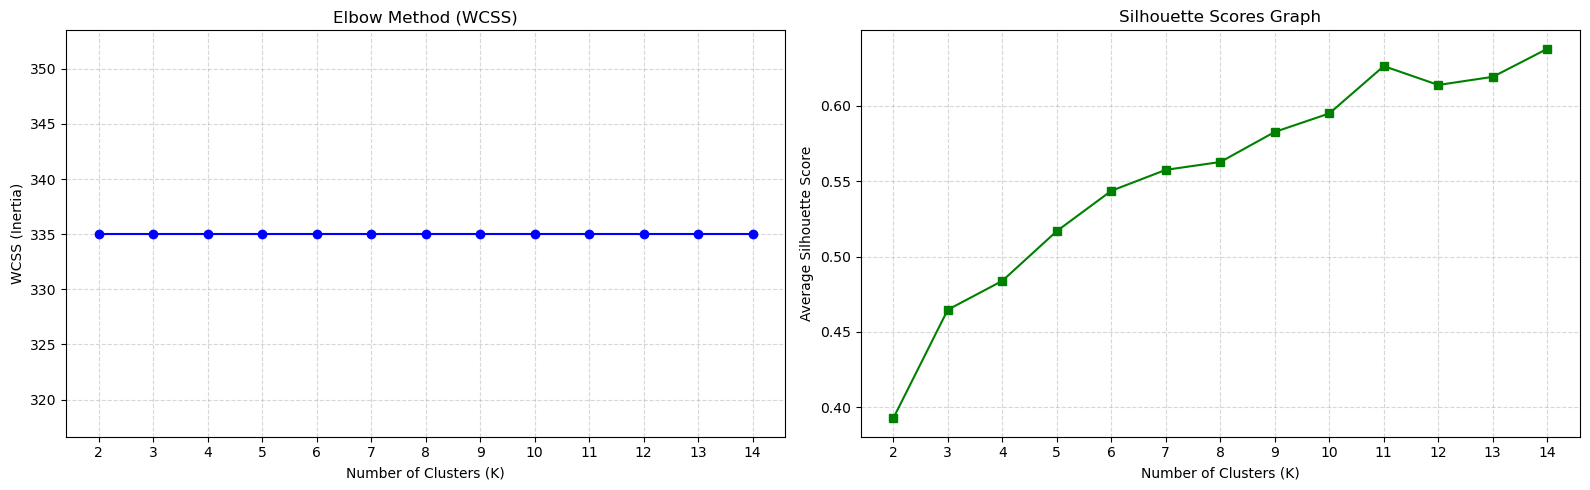

In [13]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))

# Plot Elbow Method
ax1.plot(wcss_range, wcss, marker="o", color="blue", linestyle="-")
ax1.set_title("Elbow Method (WCSS)")
ax1.set_xlabel("Number of Clusters (K)")
ax1.set_ylabel("WCSS (Inertia)")
ax1.set_xticks(wcss_range)
ax1.grid(True, linestyle="--", alpha=0.5)

# Plot Silhouette Scores
ax2.plot(k_range, silhouette_scores, marker="s", color="green", linestyle="-")
ax2.set_title("Silhouette Scores Graph")
ax2.set_xlabel("Number of Clusters (K)")
ax2.set_ylabel("Average Silhouette Score")
ax2.set_xticks(k_range)
ax2.grid(True, linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

In [ ]:
''' It is completely normal to feel this way on your first case study! The short answer: Yes, it is fine to have a "sequel" story, but for a professional case study, the distinction between them needs to be crystal clear so the "checker" (evaluator) doesn't think you just made a mistake.
Here is how to refine your approach so it looks intentional and high-quality:
## 1. Don't remove Group 1—Refine it!
I don't suggest removing it, but I do suggest removing Age. Age is a "noisy" variable; unless you are specifically studying "Gen Z vs. Boomers," it usually blurs K-Means clusters.

* The Story: "Company Culture vs. Prevalence."
* Why it works: It sets the stage. You are showing the physical reality of the workplace (remote, company size, benefits) versus the medical reality (mental health status).

## 2. How to handle Group 2 & 3 (The "Sequel" Problem)
If you want to keep both, you must rename them and frame them differently in your report so the evaluator sees them as two different "lenses."

* Group 2 (The "Psychological Safety" Lens): Frame this as the Human/Social side. It's about fear, judgment, and past experiences.
* Headline for Case Study: "How Social Stigma Paralyzes Performance."
* Group 3 (The "Institutional Support" Lens): Frame this as the Operational/Policy side. It's about anonymity and the tools the company provides.
* Headline for Case Study: "The Limits of Corporate Benefits: When Policy isn't Enough."

## 3. Why the Silhouette Score is low (and why it's okay)
In mental health data, silhouette scores of 0.2 to 0.3 are actually very common.

* Why? Human behavior isn't "tight." People are messy. Someone might have high stigma but low interference, or no stigma but high interference.
* Case Study Tip: In your final report, acknowledge the low score. Write: "The silhouette score of 0.26 indicates overlapping behaviors, suggesting that mental health interference is a complex spectrum rather than rigid categories." This shows the checker you actually understand the math.

## 4. Pro-Tip for your first Case Study
To make this look professional, follow this flow for each group:

   1. Hypothesis: "I expect that people with high stigma will report higher work interference."
   2. The Result: "The clusters showed [X]% of people feel [Y]."
   3. The Insight: "This means that even if a company is nice, if the culture is judgmental, people won't work effectively."

The verdict: Keep your 3 groups, but remove Age from Group 1, and make sure Group 2 is titled about "Culture/Stigma" and Group 3 is titled about "Support/Anonymity."
Would you like help writing the business insights or "so-what" summaries for these three specific groups? '''

In [ ]:
# Group 1 name would be Employee Health across different Workplace Environments
# Group 2 name would be Mental Health Stigma and its impact on performance
# Group 3 name should be Evaluating the Effectiveness of workplace support